In [2]:
import os
import sys
import glob
from pyhere import here
from pathlib import Path

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import seaborn as sns
import torch
import skmisc
import subprocess
from joblib import parallel_backend
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
import warnings

import zstandard as zstd
import hdf5plugin

import pickle

# My modules / functions
sys.path.append(str(here('scripts/misc')))  
import my_anndata as ma

In [3]:
# Saving
base_dir = str(here('data/integrate/first_pass/'))
file_dir = os.path.join(base_dir, 'files') 
plot_dir = os.path.join(base_dir, 'plot') 
tmp_dir = os.path.join(base_dir, 'tmp') 
emb_dir = os.path.join(base_dir, 'embedding') 
objects_dir = os.path.join(base_dir, 'objects') 

In [4]:
# Plotting
plt.style.use('default') 

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
 
SMALL_SIZE = 4
MEDIUM_SIZE = 6
BIGGER_SIZE = 8
 
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

sc.set_figure_params(figsize=(2, 2), frameon=False, dpi_save= 300)

sc.settings.figdir = plot_dir
%config InlineBackend.print_figure_kwargs={'facecolor': 'w'}
%config InlineBackend.figure_format='retina'

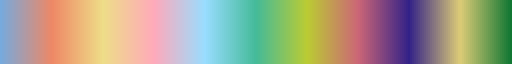

In [5]:
# Color bar
import tol_colors
import matplotlib.colors as mcolors

# Get the list of colors from each palette
light_colors = tol_colors.light[:7] # remove overlapping colors
bright_colors = tol_colors.muted[:4] # remove overlapping colors

# Combine the two lists of colors
combined_colors = light_colors + bright_colors

# Now, use this longer list to create a colormap or pass it directly to Scanpy
combined_cmap = mcolors.LinearSegmentedColormap.from_list(
    'combined_tol', combined_colors
)
combined_cmap

In [6]:
# Define what we want to color by
variables = ('study_cell_annotation_harmonized', 'technical', 'cell_nuclei',
      'ic_id_study_overall', 'library_prep', 'disease')

In [7]:
adata_paths = glob.glob(os.path.join(objects_dir, '*_pass*.h5ad'))

In [8]:
adata_paths

['/work/islet_cartography_scrna/data/integrate/first_pass/objects/first_pass_500_with_embeddings.h5ad',
 '/work/islet_cartography_scrna/data/integrate/first_pass/objects/first_pass_2000_with_embeddings.h5ad',
 '/work/islet_cartography_scrna/data/integrate/first_pass/objects/first_pass_1000_with_embeddings.h5ad']

In [31]:
from matplotlib.backends.backend_pdf import PdfPages
import os

for path in adata_paths:
    adata = sc.read_h5ad(path)

    # cell size like scanpy
    n_cells = adata.shape[0]
    marker_size = 120000 / n_cells
    
    # Extract the number from the filename
    number = int(re.search(r'first_pass_(\d+)_', path).group(1))
    
    # Get umap keys
    keys = [k for k in adata.obsm.keys() if k.startswith('X_') and k.endswith('_umap')]

    for key in keys:
        base_key = key.replace('X_', '').replace('_umap', '')
        
        # Add the number to the PDF filename
        pdf_path = os.path.join(plot_dir, f'UMAP_{base_key}_{number}.pdf')
        print(pdf_path)
        
        with PdfPages(pdf_path) as pdf:
            # Make a dataframe with umap coordinates
            df_umap = pd.DataFrame(adata.obsm[key], columns=['UMAP1','UMAP2'])
            
            ncols = len(variables)
            fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 6), sharex=True, sharey=True)

            for ax, col in zip(axes, variables):
                if col not in adata.obs:
                    ax.set_visible(False)
                    continue
                
                df_umap[col] = adata.obs[col].astype(str).values
            
                # Separate known vs unknown for cell types
                if col == 'study_cell_annotation_harmonized':
                    df_plot = df_umap[df_umap[col].str.lower() != "unknown"].copy()  # known
                    unknown_subset = df_umap[df_umap[col].str.lower() == "unknown"]  # unknown
                else:
                    df_plot = df_umap.copy()
                    unknown_subset = pd.DataFrame(columns=df_umap.columns)  # empty
            
                categories = df_plot[col].unique()
                n_categories = len(categories)
            
                # Build palette for known categories only
                if n_categories == 1:
                    palette = {categories[0]: combined_cmap(0.0)}
                else:
                    palette = {cat: combined_cmap(i/(n_categories-1)) for i, cat in enumerate(categories)}
            
                # --- Plot unknown cells first in grey ---
                if not unknown_subset.empty:
                    ax.scatter(unknown_subset['UMAP1'], unknown_subset['UMAP2'],
                               s=marker_size, color='lightgrey', linewidths=0, rasterized=True, zorder=0)
            
                # --- Plot known categories ---
                for cat in categories:
                    subset = df_plot[df_plot[col] == cat]
                    ax.scatter(subset['UMAP1'], subset['UMAP2'],
                               s=marker_size, color=palette[cat], linewidths=0, label=cat, rasterized=True, zorder=1)
            
                ax.set_axis_off()
                ax.set_title(col)
            
                # Add legend underneath this panel (for known categories only)
                ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), 
                          ncol=min(4, n_categories), fontsize=6, markerscale=6)


            # Save the **entire figure** after plotting all variables
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_pca_500.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scpoli_500_technical_20_20_500.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scpoli_500_technical_ic_id_donor_overall_20_20_500.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scvi_500_technical_20_20_500.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scvi_500_technical_ic_id_donor_overall_20_20_500.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_sysvi_500_technical_20_20_500.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_sysvi_500_technical_ic_id_donor_overall_20_20_500.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_pca_2000.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scpoli_2000_technical_20_20_2000.pdf
/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scpoli_2000_te

## Save the palette

In [ ]:
## Generate palettes
palettes = {}
adata = sc.read_h5ad(adata_paths[1])
key = "X_scpoli_2000_technical_ic_id_donor_overall_20_20_umap"

variables = ['study_cell_annotation_harmonized', 'technical', 'cell_nuclei',
             'ic_id_study_overall', 'library_prep', 'disease']

df_umap = pd.DataFrame(adata.obsm[key], columns=['UMAP1','UMAP2'])

ncols = len(variables)

for col in variables:

    df_umap[col] = adata.obs[col].astype(str).values

    # Exclude unknown only for cell types
    if col == 'study_cell_annotation_harmonized':
        df_plot = df_umap[df_umap[col].str.lower() != "unknown"].copy()
    else:
        df_plot = df_umap.copy()

    categories = df_plot[col].unique()
    n_categories = len(categories)

    # Build palette
    if n_categories == 1:
        palette = {categories[0]: combined_cmap(0.0)}
    else:
        palette = {cat: combined_cmap(i/(n_categories-1)) for i, cat in enumerate(categories)}

    # save palette
    palettes[col] = palette


### Save palettes as plot

In [ ]:
for col, palette in palettes.items():
    n = len(palette)
    fig, ax = plt.subplots(figsize=(max(n * 0.5, 6), 4))  # taller figure

    for i, (cat, color) in enumerate(palette.items()):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))

    ax.set_xlim(0, n)
    ax.set_ylim(0, 1)

    ax.set_xticks(range(n))
    ax.set_xticklabels(palette.keys(), rotation=45, ha='right', fontsize=8)
    ax.set_yticks([])

    plt.title(col)
    plt.subplots_adjust(bottom=0.25, top=0.85)  # increase bottom margin for labels
    plt.savefig(os.path.join(plot_dir, f'{col}_colormap.pdf'), dpi=300)
    plt.close()

### Save palettes as csv

In [ ]:
for col, palette in palettes.items():
    df_pal = pd.DataFrame({'category': list(palette.keys()),
                           'color': [f'rgba{tuple(int(255*c) for c in color[:3])}' for color in palette.values()]})
    df_pal.to_csv(os.path.join(file_dir, f'{col}_colormap.csv'), index=False)

## Plot umap and color by each category in its own plot - facetwrap style

In [8]:
# Just the integration winner
adata = sc.read_h5ad(adata_paths[2])
key = "X_scpoli_1000_technical_ic_id_donor_overall_20_20_umap"
colors = ('study_cell_annotation_harmonized', 'technical', 'cell_nuclei',
          'ic_id_study_overall', 'library_prep', 'disease')

# cell size like scanpy
n_cells = adata.shape[0]
marker_size = 120000 / n_cells

df_umap = pd.DataFrame(adata.obsm[key], columns=['UMAP1','UMAP2'])

pdf_path = os.path.join(plot_dir, f'UMAP_scpoli_1000_technical_ic_id_donor_overall_20_20_2000_facet.pdf')
print(pdf_path)
with PdfPages(pdf_path) as pdf:
            
    for col in colors:
        if col not in adata.obs:
            continue
    
        df_umap[col] = adata.obs[col].astype(str).values
        
        # Exclude unknown only for cell types
        if col == 'study_cell_annotation_harmonized':
            df_plot = df_umap[df_umap[col].str.lower() != "unknown"].copy() 
        else:
            df_plot = df_umap.copy()
    
        # Generate palette
        categories = df_plot[col].unique()
        n_categories = len(categories)
    
        # If there is only one category, just choose the first color
        if n_categories == 1:
            palette = {categories[0]: combined_cmap(0.0)}
        else:
            palette = {cat: combined_cmap(i / (n_categories - 1)) for i, cat in enumerate(categories)}
    
        # Add a column that will be used for faceting: which is the category itself
        df_plot['facet'] = df_plot[col]
    
        # Number of columns
        ncols = 6
        g = sns.FacetGrid(df_plot, col="facet", col_wrap=ncols, sharex=True, sharey=True)
        
        for ax, cat in zip(g.axes.flatten(), categories):
            # plot full grey background
            ax.scatter(df_umap['UMAP1'], df_umap['UMAP2'], s=marker_size, color='lightgrey', alpha=0.6, linewidths=0, rasterized=True)
            
            # overlay colored points for this category
            subset = df_plot[df_plot[col] == cat]
            ax.scatter(subset['UMAP1'], subset['UMAP2'], s=3, color=palette[cat], linewidths=0, rasterized=True)
            
            ax.set_axis_off()
            ax.set_title(cat)

        pdf.savefig(g.fig, bbox_inches='tight')
        plt.close(g.fig)

/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scpoli_1000_technical_ic_id_donor_overall_20_20_2000_facet.pdf


In [9]:
# Just the integration winner - PCA
adata = sc.read_h5ad(adata_paths[2])
key = "X_X_pca_umap"
colors = ('study_cell_annotation_harmonized', 'technical', 'cell_nuclei',
          'ic_id_study_overall', 'library_prep', 'disease')

# cell size like scanpy
n_cells = adata.shape[0]
marker_size = 120000 / n_cells

df_umap = pd.DataFrame(adata.obsm[key], columns=['UMAP1','UMAP2'])

pdf_path = os.path.join(plot_dir, f'UMAP_pca_1000_facet.pdf')
print(pdf_path)
with PdfPages(pdf_path) as pdf:
            
    for col in colors:
        if col not in adata.obs:
            continue
    
        df_umap[col] = adata.obs[col].astype(str).values
        
        # Exclude unknown only for cell types
        if col == 'study_cell_annotation_harmonized':
            df_plot = df_umap[df_umap[col].str.lower() != "unknown"].copy() 
        else:
            df_plot = df_umap.copy()
    
        # Generate palette
        categories = df_plot[col].unique()
        n_categories = len(categories)
    
        # If there is only one category, just choose the first color
        if n_categories == 1:
            palette = {categories[0]: combined_cmap(0.0)}
        else:
            palette = {cat: combined_cmap(i / (n_categories - 1)) for i, cat in enumerate(categories)}
    
        # Add a column that will be used for faceting: which is the category itself
        df_plot['facet'] = df_plot[col]
    
        # Number of columns
        ncols = 6
        g = sns.FacetGrid(df_plot, col="facet", col_wrap=ncols, sharex=True, sharey=True)
        
        for ax, cat in zip(g.axes.flatten(), categories):
            # plot full grey background
            ax.scatter(df_umap['UMAP1'], df_umap['UMAP2'], s=marker_size, color='lightgrey', alpha=0.6, linewidths=0, rasterized=True)
            
            # overlay colored points for this category
            subset = df_plot[df_plot[col] == cat]
            ax.scatter(subset['UMAP1'], subset['UMAP2'], s=3, color=palette[cat], linewidths=0, rasterized=True)
            
            ax.set_axis_off()
            ax.set_title(cat)

        pdf.savefig(g.fig, bbox_inches='tight')
        plt.close(g.fig)

/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_pca_1000_facet.pdf


## Do Sysvi because it looks weird

In [10]:
# Just the integration winner
adata = sc.read_h5ad(adata_paths[2])
key = "X_sysvi_1000_technical_ic_id_donor_overall_20_20_umap"
colors = ('study_cell_annotation_harmonized', 'technical', 'cell_nuclei',
          'ic_id_study_overall', 'library_prep', 'disease')

# cell size like scanpy
n_cells = adata.shape[0]
marker_size = 120000 / n_cells

df_umap = pd.DataFrame(adata.obsm[key], columns=['UMAP1','UMAP2'])

pdf_path = os.path.join(plot_dir, f'UMAP_sysvi_1000_technical_ic_id_donor_overall_20_20_2000_facet.pdf')
print(pdf_path)
with PdfPages(pdf_path) as pdf:
            
    for col in colors:
        if col not in adata.obs:
            continue
    
        df_umap[col] = adata.obs[col].astype(str).values
        
        # Exclude unknown only for cell types
        if col == 'study_cell_annotation_harmonized':
            df_plot = df_umap[df_umap[col].str.lower() != "unknown"].copy() 
        else:
            df_plot = df_umap.copy()
    
        # Generate palette
        categories = df_plot[col].unique()
        n_categories = len(categories)
    
        # If there is only one category, just choose the first color
        if n_categories == 1:
            palette = {categories[0]: combined_cmap(0.0)}
        else:
            palette = {cat: combined_cmap(i / (n_categories - 1)) for i, cat in enumerate(categories)}
    
        # Add a column that will be used for faceting: which is the category itself
        df_plot['facet'] = df_plot[col]
    
        # Number of columns
        ncols = 6
        g = sns.FacetGrid(df_plot, col="facet", col_wrap=ncols, sharex=True, sharey=True)
        
        for ax, cat in zip(g.axes.flatten(), categories):
            # plot full grey background
            ax.scatter(df_umap['UMAP1'], df_umap['UMAP2'], s=marker_size, color='lightgrey', alpha=0.6, linewidths=0, rasterized=True)
            
            # overlay colored points for this category
            subset = df_plot[df_plot[col] == cat]
            ax.scatter(subset['UMAP1'], subset['UMAP2'], s=3, color=palette[cat], linewidths=0, rasterized=True)
            
            ax.set_axis_off()
            ax.set_title(cat)

        pdf.savefig(g.fig, bbox_inches='tight')
        plt.close(g.fig)

/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_sysvi_1000_technical_ic_id_donor_overall_20_20_2000_facet.pdf


In [11]:
# Just the integration winner
adata = sc.read_h5ad(adata_paths[2])
key = "X_scvi_1000_technical_ic_id_donor_overall_20_20_umap"
colors = ('study_cell_annotation_harmonized', 'technical', 'cell_nuclei',
          'ic_id_study_overall', 'library_prep', 'disease')

# cell size like scanpy
n_cells = adata.shape[0]
marker_size = 120000 / n_cells

df_umap = pd.DataFrame(adata.obsm[key], columns=['UMAP1','UMAP2'])

pdf_path = os.path.join(plot_dir, f'UMAP_scvi_1000_technical_ic_id_donor_overall_20_20_2000_facet.pdf')
print(pdf_path)
with PdfPages(pdf_path) as pdf:
            
    for col in colors:
        if col not in adata.obs:
            continue
    
        df_umap[col] = adata.obs[col].astype(str).values
        
        # Exclude unknown only for cell types
        if col == 'study_cell_annotation_harmonized':
            df_plot = df_umap[df_umap[col].str.lower() != "unknown"].copy() 
        else:
            df_plot = df_umap.copy()
    
        # Generate palette
        categories = df_plot[col].unique()
        n_categories = len(categories)
    
        # If there is only one category, just choose the first color
        if n_categories == 1:
            palette = {categories[0]: combined_cmap(0.0)}
        else:
            palette = {cat: combined_cmap(i / (n_categories - 1)) for i, cat in enumerate(categories)}
    
        # Add a column that will be used for faceting: which is the category itself
        df_plot['facet'] = df_plot[col]
    
        # Number of columns
        ncols = 6
        g = sns.FacetGrid(df_plot, col="facet", col_wrap=ncols, sharex=True, sharey=True)
        
        for ax, cat in zip(g.axes.flatten(), categories):
            # plot full grey background
            ax.scatter(df_umap['UMAP1'], df_umap['UMAP2'], s=marker_size, color='lightgrey', alpha=0.6, linewidths=0, rasterized=True)
            
            # overlay colored points for this category
            subset = df_plot[df_plot[col] == cat]
            ax.scatter(subset['UMAP1'], subset['UMAP2'], s=3, color=palette[cat], linewidths=0, rasterized=True)
            
            ax.set_axis_off()
            ax.set_title(cat)

        pdf.savefig(g.fig, bbox_inches='tight')
        plt.close(g.fig)

/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_scvi_1000_technical_ic_id_donor_overall_20_20_2000_facet.pdf


## SysVI 2000

In [9]:
# Just the integration winner
adata = sc.read_h5ad(adata_paths[1])
key = "X_sysvi_2000_technical_ic_id_donor_overall_20_20_umap"
colors = ('study_cell_annotation_harmonized', 'technical', 'cell_nuclei',
          'ic_id_study_overall', 'library_prep', 'disease')

# cell size like scanpy
n_cells = adata.shape[0]
marker_size = 120000 / n_cells

df_umap = pd.DataFrame(adata.obsm[key], columns=['UMAP1','UMAP2'])

pdf_path = os.path.join(plot_dir, f'UMAP_sysvi_2000_technical_ic_id_donor_overall_20_20_2000_facet.pdf')
print(pdf_path)
with PdfPages(pdf_path) as pdf:
            
    for col in colors:
        if col not in adata.obs:
            continue
    
        df_umap[col] = adata.obs[col].astype(str).values
        
        # Exclude unknown only for cell types
        if col == 'study_cell_annotation_harmonized':
            df_plot = df_umap[df_umap[col].str.lower() != "unknown"].copy() 
        else:
            df_plot = df_umap.copy()
    
        # Generate palette
        categories = df_plot[col].unique()
        n_categories = len(categories)
    
        # If there is only one category, just choose the first color
        if n_categories == 1:
            palette = {categories[0]: combined_cmap(0.0)}
        else:
            palette = {cat: combined_cmap(i / (n_categories - 1)) for i, cat in enumerate(categories)}
    
        # Add a column that will be used for faceting: which is the category itself
        df_plot['facet'] = df_plot[col]
    
        # Number of columns
        ncols = 6
        g = sns.FacetGrid(df_plot, col="facet", col_wrap=ncols, sharex=True, sharey=True)
        
        for ax, cat in zip(g.axes.flatten(), categories):
            # plot full grey background
            ax.scatter(df_umap['UMAP1'], df_umap['UMAP2'], s=marker_size, color='lightgrey', alpha=0.6, linewidths=0, rasterized=True)
            
            # overlay colored points for this category
            subset = df_plot[df_plot[col] == cat]
            ax.scatter(subset['UMAP1'], subset['UMAP2'], s=3, color=palette[cat], linewidths=0, rasterized=True)
            
            ax.set_axis_off()
            ax.set_title(cat)

        pdf.savefig(g.fig, bbox_inches='tight')
        plt.close(g.fig)

/work/islet_cartography_scrna/data/integrate/first_pass/plot/UMAP_sysvi_2000_technical_ic_id_donor_overall_20_20_2000_facet.pdf
